In [6]:
import tensorflow as tf
import sys
import os
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt
import numpy as np
import cv2
from tensorflow.keras.datasets import mnist

#data를 읽어 온 후 학습시와 동일하게 foramt을 변경 
(X_train, Y_class_train), (X_test, Y_class_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1).astype('float32') / 255

model = load_model('./model/07-0.0286.keras')
model.summary()

wrong_result = []
predicted_result = model.predict(X_test)
predicted_labels = np.argmax(predicted_result, axis = 1)
for n in range(0, len(Y_class_test)):
    if predicted_labels[n] != Y_class_test[n]:
        wrong_result.append(n)
len(wrong_result)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,599,648 (13.73 MB)

 Trainable params: 1,199,882 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,399,766 (9.15 MB)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


95

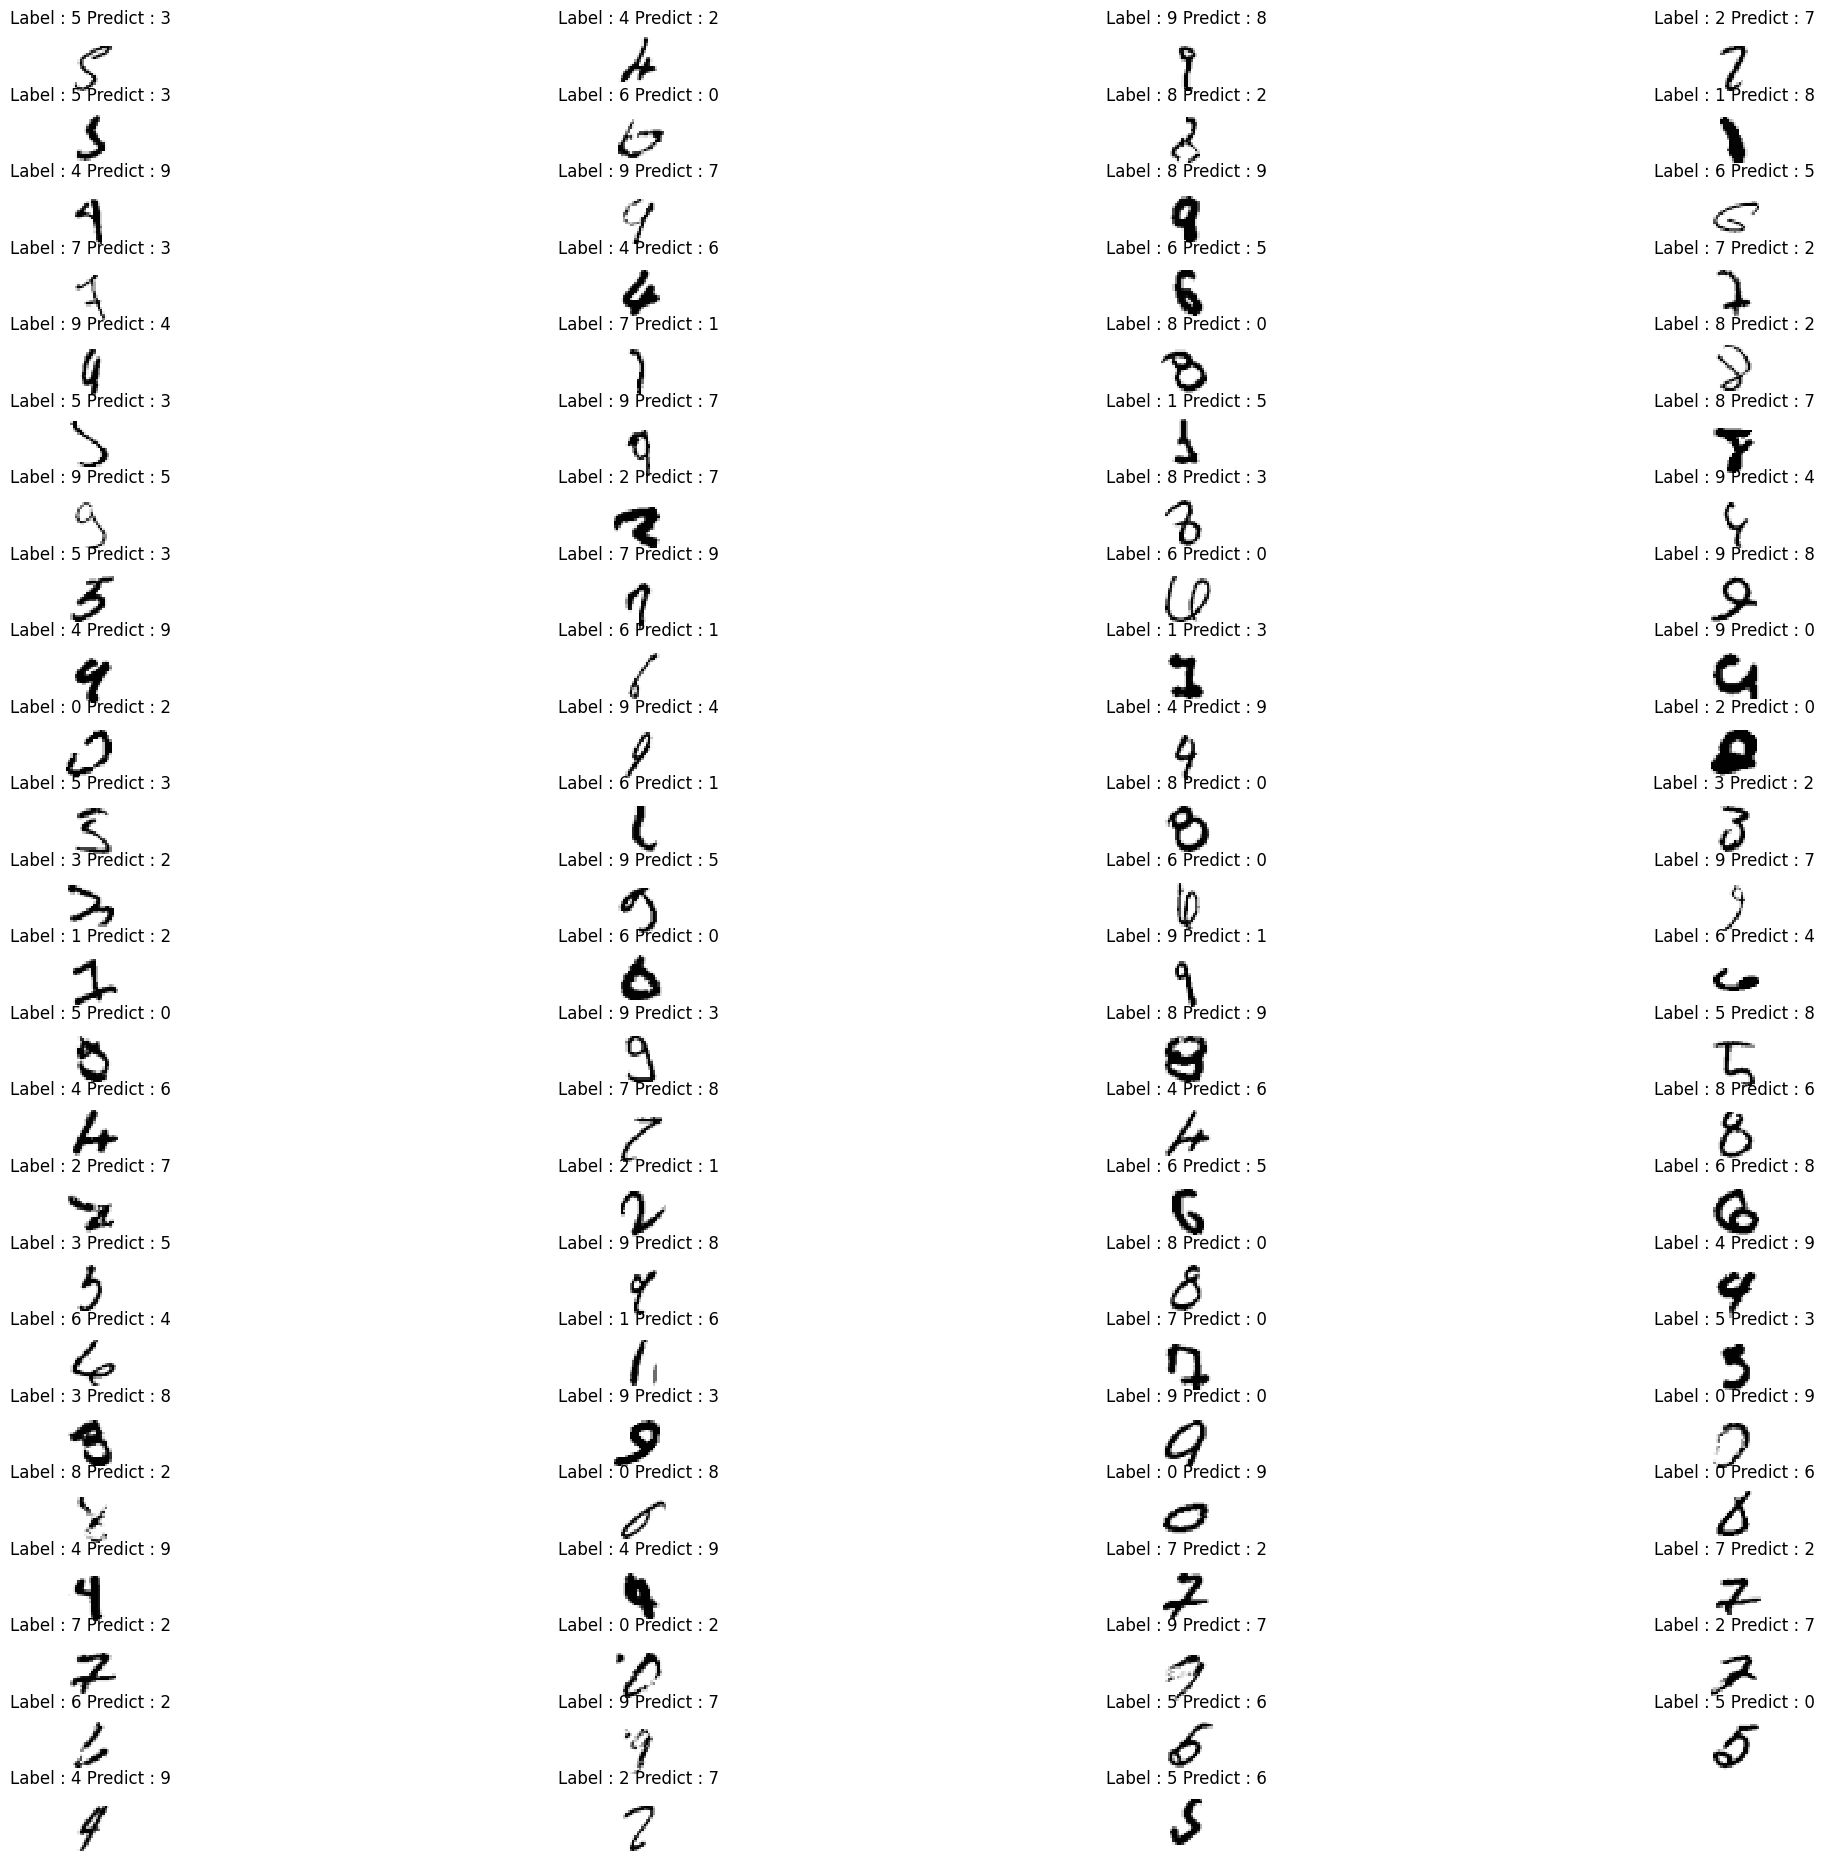

In [7]:
plt.figure(figsize=(14, 12))
 
for idx, n in enumerate(wrong_result):    
    # wrong_result 이 결과를 모두 표시해야 함	
    # 한줄에 4개를 표시 하므로 마지막에 0에서 4개가 남음 이거에 대비해서 한줄을 더 만들어 줌
    plt.subplot(len(wrong_result)//4+1, 4, idx + 1) #결과가 정수로 나와야 하므로 몫 연산자로 정수만 취함
    plt.subplots_adjust(left=0.0, bottom=0.0,  right=1.5, top=1.52)
    plt.imshow(X_test[n].reshape(28, 28), cmap = 'Greys', interpolation='nearest')
    plt.title( 'Label : ' + str(Y_class_test[n]) + ' Predict : ' + str(predicted_labels[n]))
    plt.axis('off')
    
plt.show()
